# CA Traffic Simulation
## ARIMA + Nagel-Schreckenberg + GA

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, random, os, warnings
warnings.filterwarnings('ignore')
import statsmodels.api as sm
from deap import base, creator, tools, algorithms
import seaborn as sns; sns.set_theme(style='whitegrid'); plt.rcParams['figure.dpi'] = 150
O = 'outputs/toronto_ca'; os.makedirs(O, exist_ok=True); print('Ready')

Ready


## 1. Seasonal ARIMA (1,1,1)(1,1,1,12)

147 months: 2014-01-01 00:00:00 to 2026-03-01 00:00:00


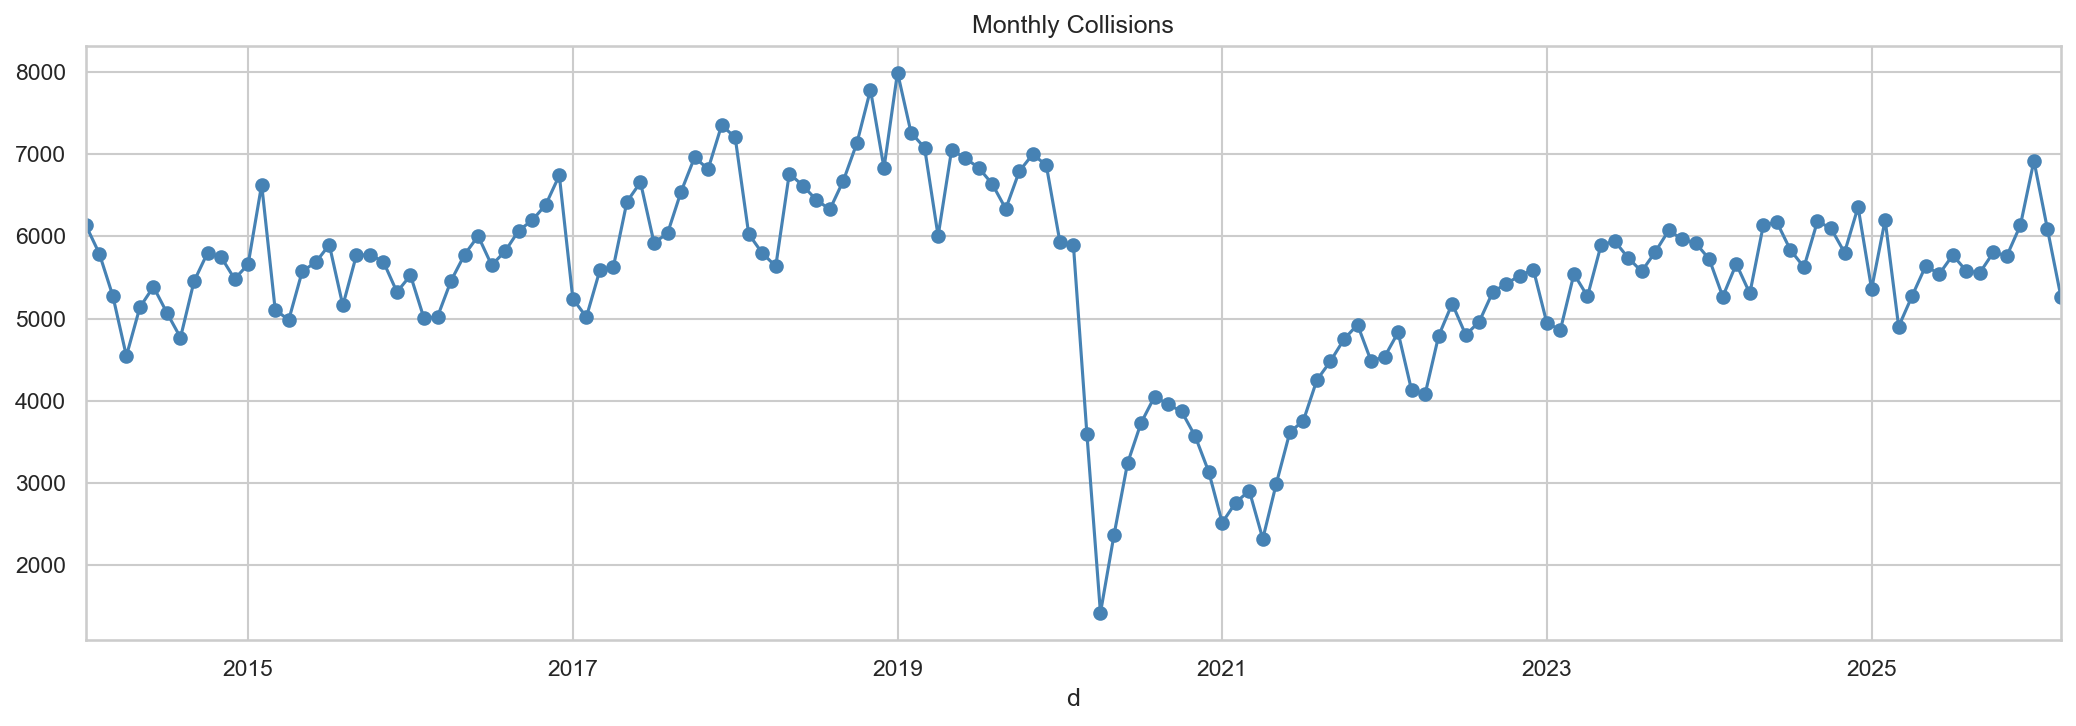

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  147
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -928.338
Date:                            Wed, 27 May 2026   AIC                           1866.676
Time:                                    02:52:06   BIC                           1880.613
Sample:                                01-01-2014   HQIC                          1872.336
                                     - 03-01-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4700      0.334      1.409      0.159      -0.184       1.124
ma.L1         -0.6292      0.311   

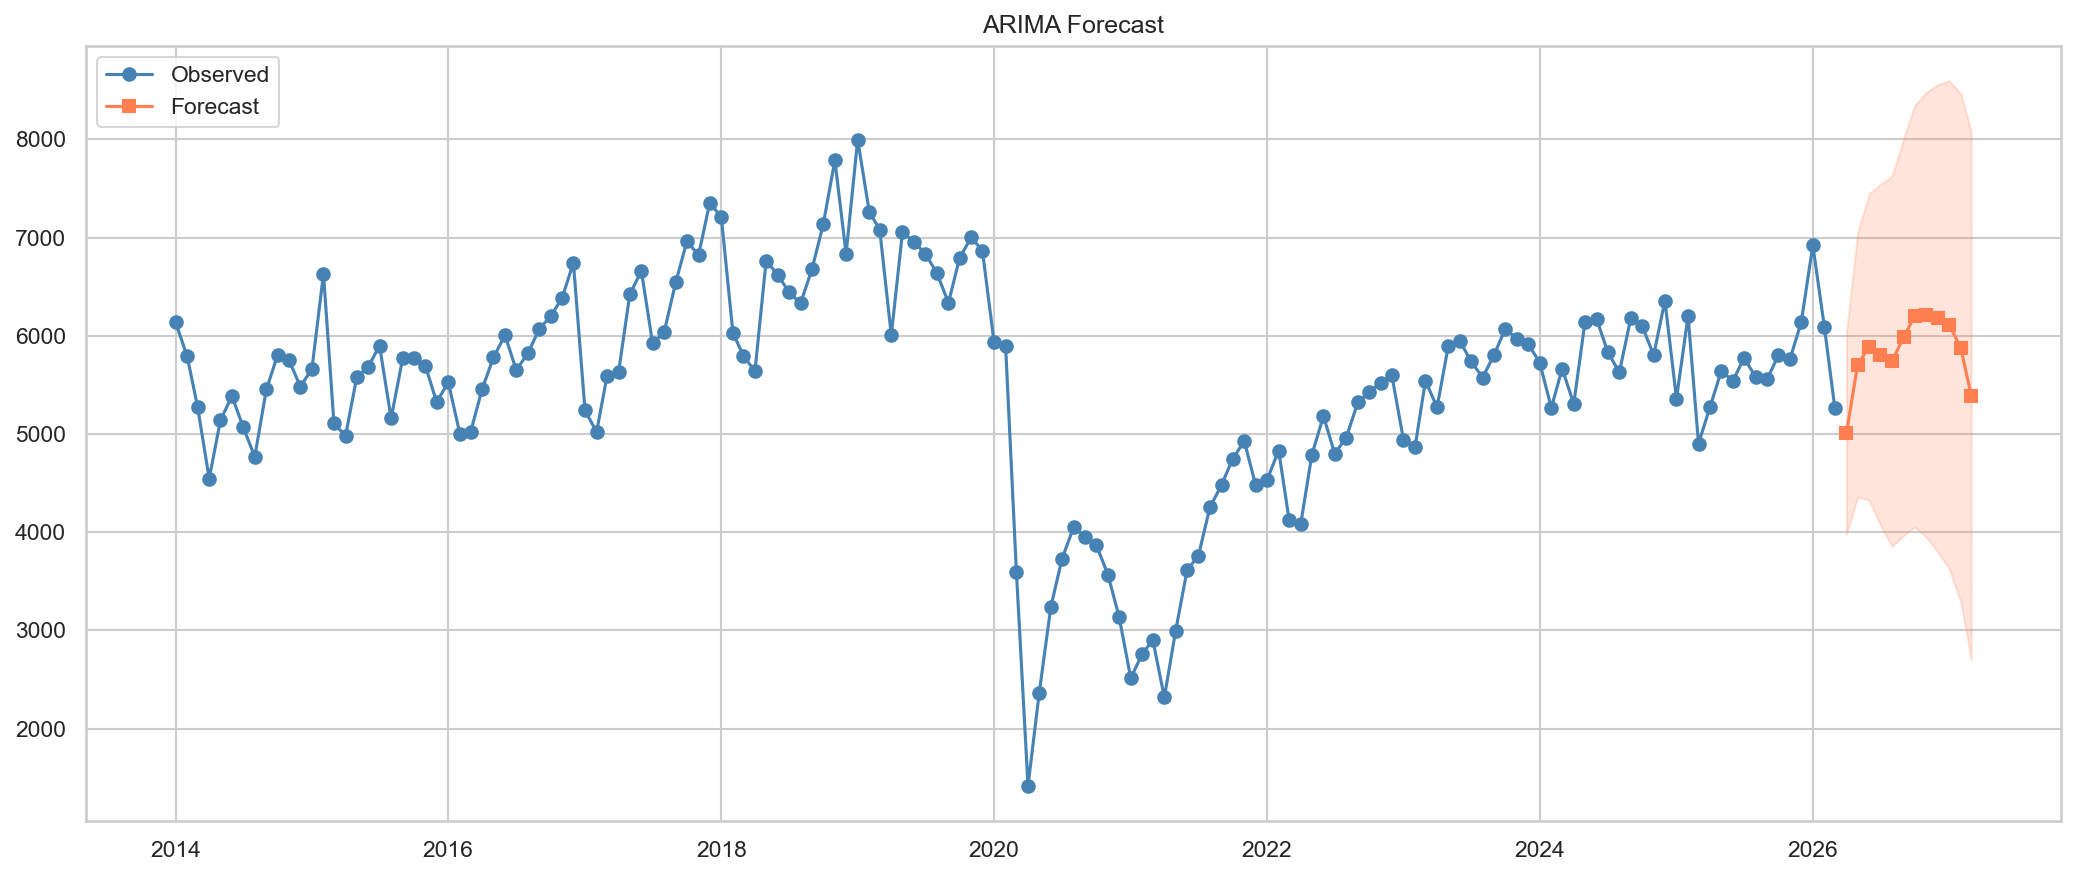

In [2]:
coll = pd.read_csv(r'data\\toronto-dataset\\new\\Traffic_Collisions_Open_Data_2053198073974531286.csv', low_memory=False)
coll['d'] = pd.to_datetime(coll['OCC_DATE'], errors='coerce')
m = coll.groupby(coll['d'].dt.to_period('M')).size(); m.index = m.index.to_timestamp()
print(f'{len(m)} months: {m.index.min()} to {m.index.max()}')
fig,ax=plt.subplots(figsize=(14,5)); m.plot(ax=ax,marker='o',color='steelblue')
ax.set_title('Monthly Collisions'); plt.tight_layout(); plt.savefig(f'{O}/monthly.png',dpi=150); plt.show()
fit = sm.tsa.statespace.SARIMAX(m,order=(1,1,1),seasonal_order=(1,1,1,12),
                                enforce_stationarity=False,enforce_invertibility=False).fit(disp=False)
print(fit.summary())
fc = fit.get_forecast(12); fcm = fc.predicted_mean; fcci = fc.conf_int()
print('\nForecast:')
for i,(idx,val) in enumerate(fcm.items()): print(f'  {idx.strftime("%Y-%m")}: {val:.0f} [{fcci.iloc[i,0]:.0f}, {fcci.iloc[i,1]:.0f}]')
fig,ax=plt.subplots(figsize=(14,6))
ax.plot(m.index,m.values,'o-',label='Observed',color='steelblue')
ax.plot(fcm.index,fcm.values,'s-',label='Forecast',color='coral')
ax.fill_between(fcm.index,fcci.iloc[:,0],fcci.iloc[:,1],color='coral',alpha=.2)
ax.legend(); ax.set_title('ARIMA Forecast'); plt.tight_layout(); plt.savefig(f'{O}/sarima.png',dpi=150); plt.show()

## 2. Cellular Automata (Nagel-Schreckenberg)

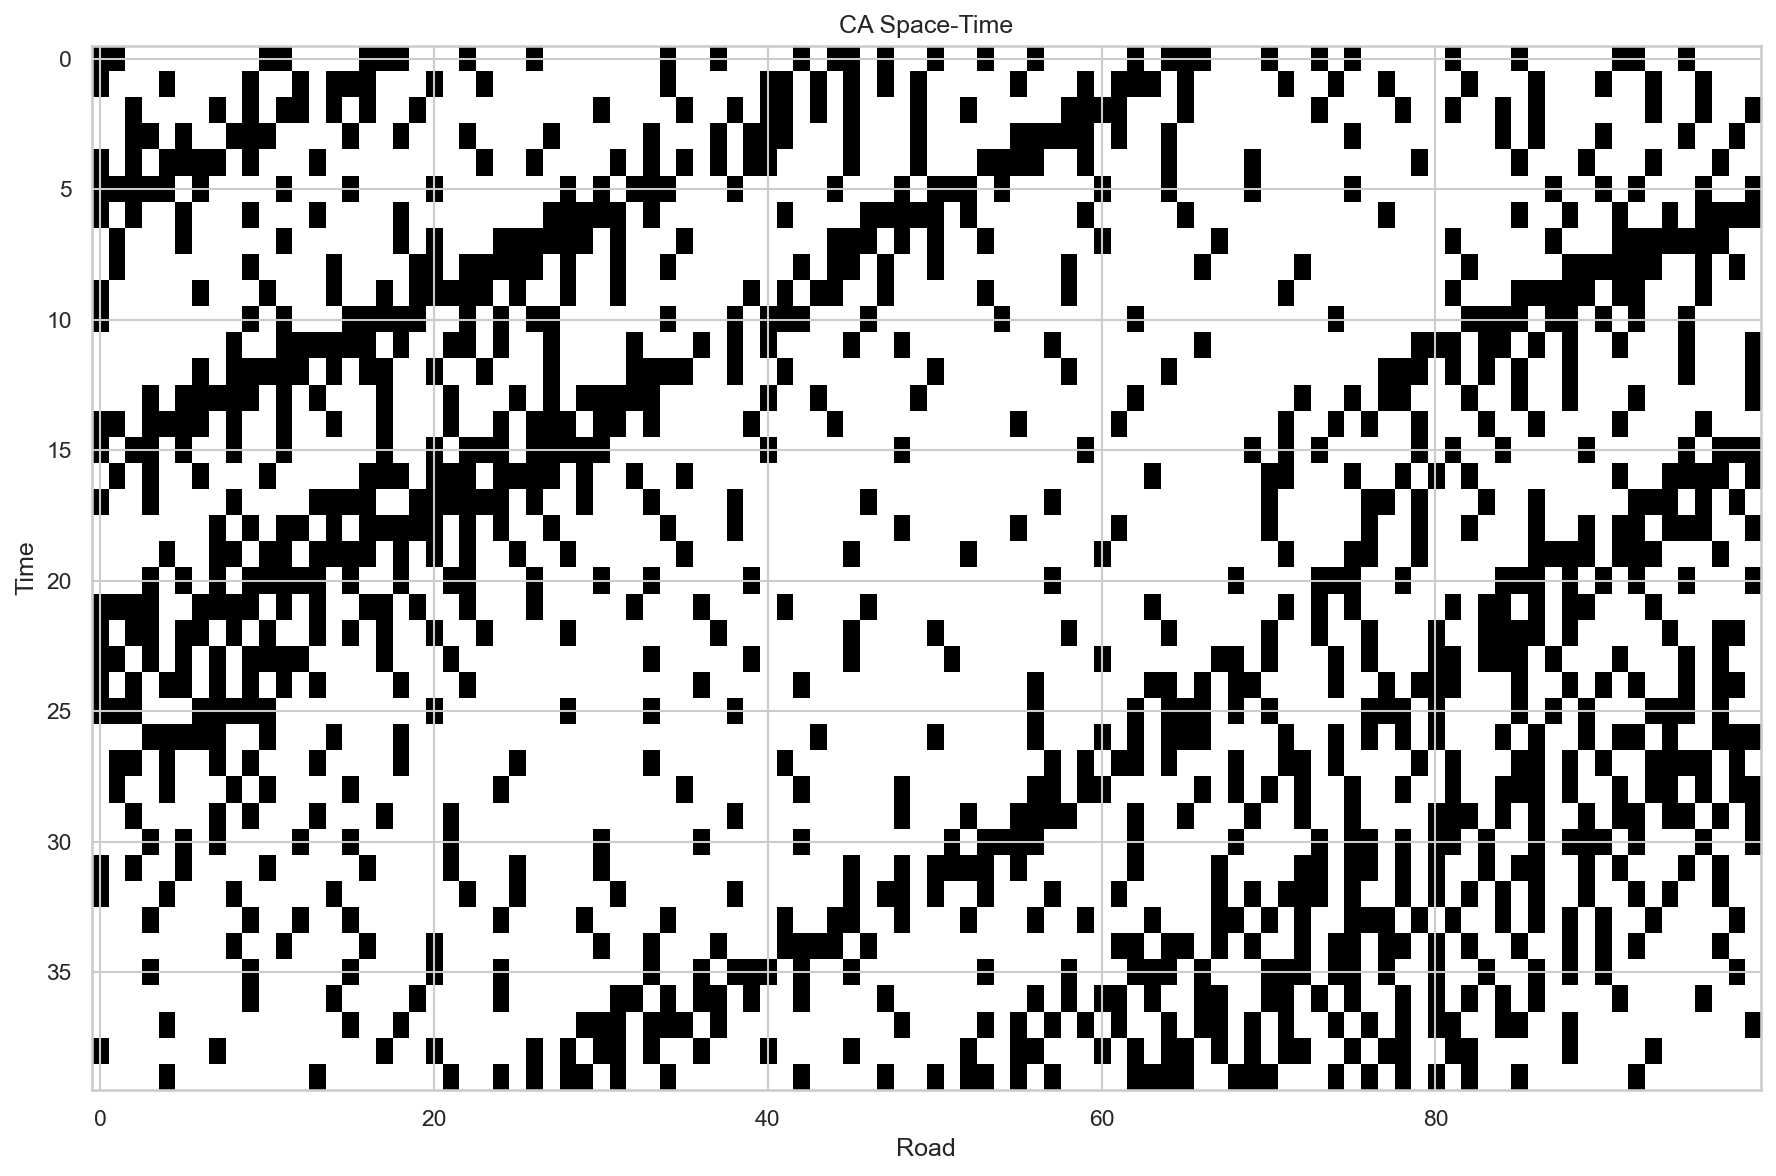

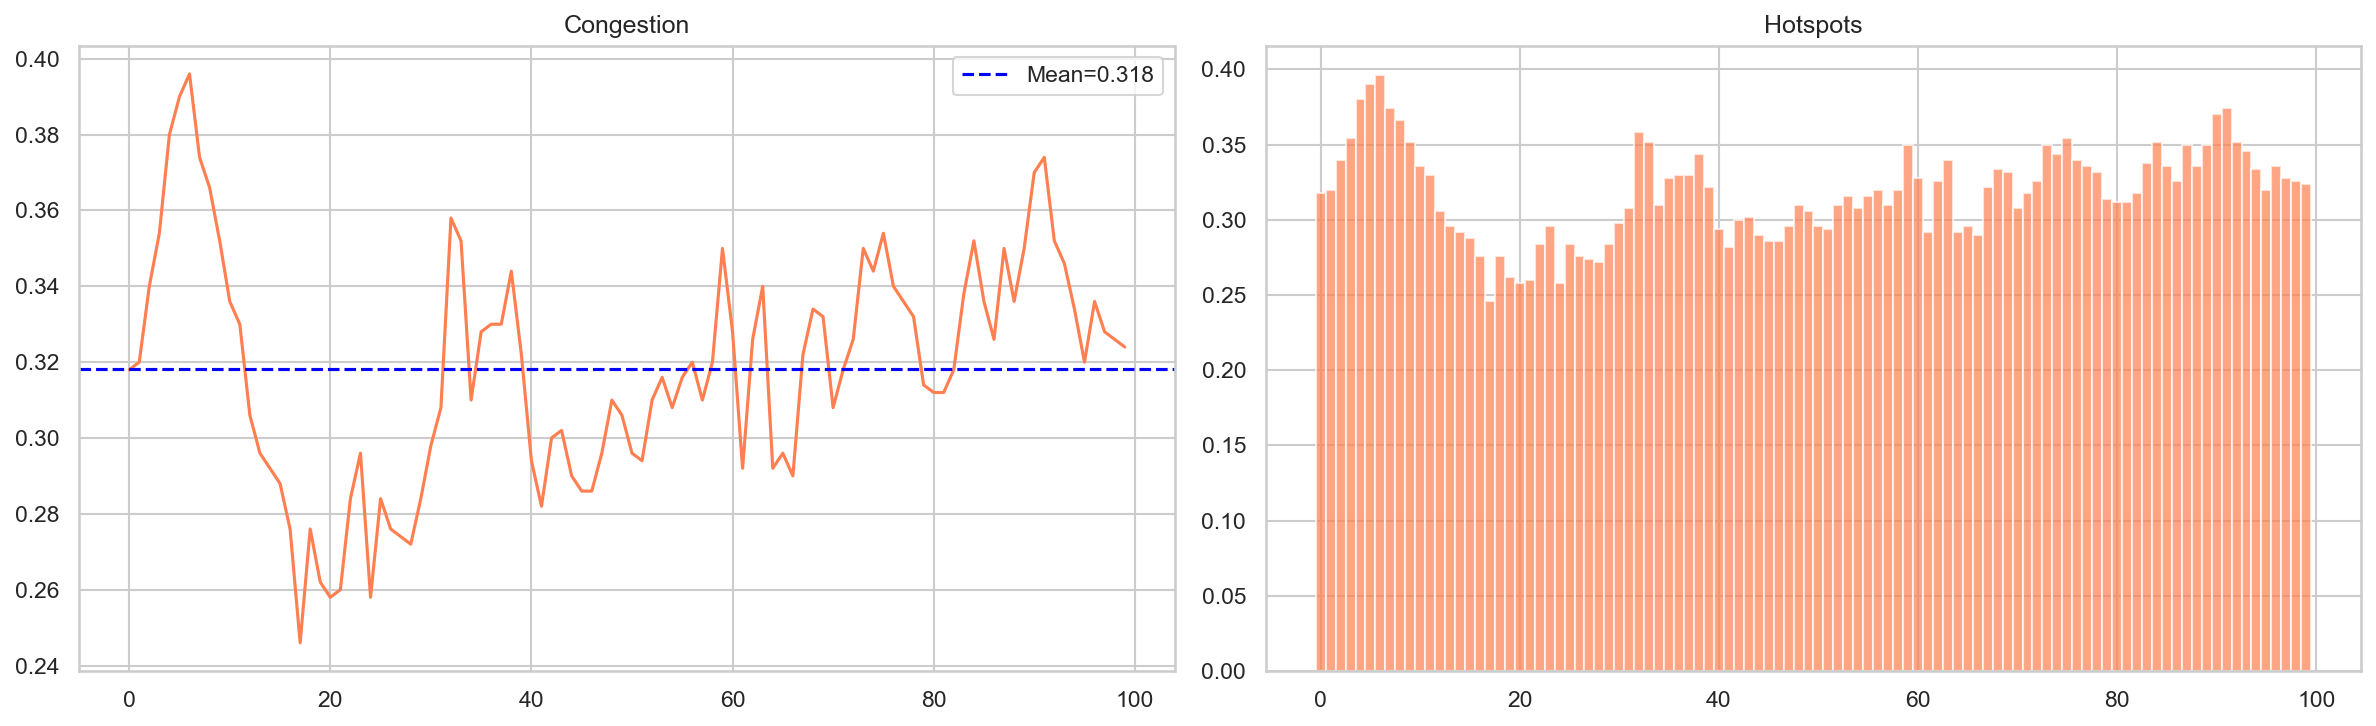

Hotspots: 19 cells


In [3]:
class CA:
    def __init__(s,L=100,d=0.3,v=5,ps=0.3,pr=0.1,lc=0.2):
        s.L,s.d,s.vmax,s.ps,s.pr,s.lc=L,d,v,ps,pr,lc; s.reset()
    def reset(s):
        n=int(s.L*s.d); p=sorted(random.sample(range(s.L),n))
        s.r=np.zeros(s.L,int); s.r[p]=1; s.v=np.random.randint(0,s.vmax+1,s.L); s.v[s.r==0]=0
    def gap(s,p):
        for i in range(1,s.L):
            if s.r[(p+i)%s.L]: return i
        return s.L
    def step(s):
        nr,nv=np.zeros(s.L,int),np.zeros(s.L,int)
        for p in np.where(s.r==1)[0]:
            v=s.v[p]; g=s.gap(p); v=min(v+1,s.vmax); v=min(v,g-1)
            if random.random()<s.ps: v=max(v-1,0)
            np_=(p+v)%s.L; nr[np_]=1; nv[np_]=v
        s.r,s.v=nr,nv
    def run(s,st=200):
        h=[]
        for t in range(st):
            s.step()
            if t%5==0: h.append(s.r.copy())
        return np.array(h)
    def cong(s,st=300):
        c=np.zeros(s.L)
        for _ in range(st):
            s.step()
            for p in range(s.L):
                if s.r[p] and s.v[p]<=1: c[p]+=1
        return c/st

ca=CA(100,0.3,5,0.3,0.1,0.2); ca.reset(); st=ca.run(200)
fig,ax=plt.subplots(figsize=(12,8))
ax.imshow(st,aspect='auto',cmap='binary',interpolation='none')
ax.set_xlabel('Road'); ax.set_ylabel('Time'); ax.set_title('CA Space-Time')
plt.tight_layout(); plt.savefig(f'{O}/ca_st.png',dpi=150); plt.show()
ca2=CA(100,0.4,5,0.3,0.1,0.2); ca2.reset(); c=ca2.cong(500)
fig,ax=plt.subplots(1,2,figsize=(16,5))
ax[0].plot(c,color='coral'); ax[0].axhline(c.mean(),color='blue',ls='--',label=f'Mean={c.mean():.3f}')
ax[0].legend(); ax[0].set_title('Congestion')
ax[1].bar(range(len(c)),c,width=1,color='coral',alpha=.7); ax[1].set_title('Hotspots')
plt.tight_layout(); plt.savefig(f'{O}/ca_cong.png',dpi=150); plt.show()
print(f'Hotspots: {(c>np.percentile(c,80)).sum()} cells')

## 3. Genetic Algorithm

In [4]:
SEED = 42
# Ground truth: deterministic CA run with paper params
true_params = [0.3, 0.1, 0.2]
random.seed(SEED); np.random.seed(SEED)
ca_true = CA(100, 0.4, 5, true_params[0], true_params[1], true_params[2])
ca_true.reset()
target = ca_true.cong(200)
print(f'Ground truth params: {true_params}')
print(f'Target congestion mean: {target.mean():.4f}')

def acc(p):
    random.seed(SEED); np.random.seed(SEED)  # deterministic
    c = CA(100, 0.4, 5, p[0], p[1], p[2]); c.reset()
    s = c.cong(200)
    o = np.sum((s > s.mean()).astype(int) == (target > target.mean()).astype(int))
    return o / len(s),

paper_acc = acc(true_params)[0]
print(f'Paper params accuracy: {paper_acc:.4f} (expected 1.0)')

creator.create('FMax',base.Fitness,weights=(1.,)); creator.create('Ind',list,fitness=creator.FMax)
tb=base.Toolbox()
tb.register('a',random.uniform,0,.5); tb.register('i',tools.initRepeat,creator.Ind,tb.a,n=3)
tb.register('pop',tools.initRepeat,list,tb.i)
tb.register('e',lambda i:acc(i)); tb.register('mate',tools.cxBlend,alpha=.5)
tb.register('mutate',tools.mutGaussian,mu=0,sigma=.1,indpb=.3); tb.register('sel',tools.selTournament,tournsize=3)
random.seed(SEED); np.random.seed(SEED); pop=tb.pop(n=15)
for g in range(8):
    off=algorithms.varAnd(pop,tb,.7,.2); fits=tb.map(tb.e,off)
    for f,i in zip(fits,off): i.fitness.values=f
    pop=tb.sel(off,k=len(pop)); fa=[i.fitness.values[0] for i in pop]
    print(f'Gen {g}: best={max(fa):.4f} avg={np.mean(fa):.4f}')
best_i = fa.index(max(fa))
print(f'Best GA params: {pop[best_i]}, acc={max(fa):.4f}')

Ground truth params: [0.3, 0.1, 0.2]
Target congestion mean: 0.3090
Paper params accuracy: 1.0000 (expected 1.0)


Gen 0: best=0.7600 avg=0.6660


Gen 1: best=0.7600 avg=0.7173


Gen 2: best=0.8500 avg=0.7407


Gen 3: best=0.8500 avg=0.7987


Gen 4: best=0.8500 avg=0.7907


Gen 5: best=0.8500 avg=0.8340


Gen 6: best=0.8500 avg=0.8500


Gen 7: best=0.8500 avg=0.8500
Best GA params: [0.27185393984703804, 0.11247010523919815, 0.10517868409116404], acc=0.8500


## 4. Results
- ARIMA: 12-month forecast
- CA: Nagel-Schreckenberg mo phong un tac
- GA: Toi uu tham so CA